In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
rows_to_read = 1000
df_merge = pd.read_csv('../raw_data/train_merge.csv', nrows = rows_to_read)


In [3]:
float_columns = []
int_columns = []
object_columns = []
for a,b in zip(df_merge.columns, list(df_merge.dtypes)):
    if b == 'int64':
        int_columns.append(a)
    elif b=='float64':
        float_columns.append(a)
    else:
        object_columns.append(a)
print(len(float_columns+int_columns))



403


## Measuring Correlation between Numeric Columns and Fraud

In [4]:
n_rows_total = 0
n_rows = {c:0 for c in int_columns+float_columns}
mins = {c:float('inf') for c in int_columns+float_columns}
maxs = {c:-float('inf') for c in int_columns+float_columns}
sums = {c:0 for c in int_columns+float_columns}
square_sums = {c:0 for c in int_columns+float_columns}
covariance_sums = {c:0 for c in int_columns+float_columns}
square_sums_red = {c:0 for c in int_columns+float_columns}
fraud_counts = {c:0 for c in int_columns+float_columns}

print_st = True
for chunk in pd.read_csv('../raw_data/train_merge.csv', chunksize = 10000):
    n_rows_total += chunk.shape[0]
    for c in int_columns+float_columns:
        vals = chunk[['isFraud',c]].dropna().to_numpy()
        rho = vals[:,0]
        vals = vals[:,1]
        if len(vals)==0:
            continue
        mins[c] = min(mins[c],vals.min())
        maxs[c] = max(maxs[c], vals.max())
        sums[c] += vals.sum()
        square_sums[c] = square_sums[c] + np.float128(np.sum(vals**2))
        n_rows[c] += np.float32(len(vals))
        covariance_sums[c] += np.dot(rho,vals)
        fraud_counts[c] += rho.sum()

In [5]:
for c,v in n_rows.items():
    print(c, np.round(v/n_rows_total, 4), np.round(sums[c]/v,4),  np.round(square_sums[c]/v-(sums[c]/v)**2,4))   

TransactionID 1.0 3282269.5 29061457633.25
isFraud 1.0 0.035 0.0338
TransactionDT 1.0 7372311.3101 21318718101724.589
card1 1.0 9898.7347 24021428.1964
TransactionAmt 1.0 135.0272 57198.6151
card2 0.9849 362.5555 24898.6658
card3 0.9973 153.1949 128.5147
card5 0.9928 199.2789 1701.102
addr1 0.8887 290.7338 10351.226
addr2 0.8887 86.8006 7.2394
dist1 0.4035 118.5022 138288.2237
dist2 0.0637 231.8554 279890.1603
C1 1.0 14.0925 17840.6524
C2 1.0 15.2697 23922.4279
C3 1.0 0.0056 0.0227
C4 1.0 4.0922 4740.1022
C5 1.0 5.5715 664.967
C6 1.0 9.0711 5113.4522
C7 1.0 2.8485 3810.2535
C8 1.0 5.1446 9097.0569
C9 1.0 4.4802 278.0517
C10 1.0 5.2403 9135.7968
C11 1.0 10.2415 8899.3209
C12 1.0 4.0762 7511.0206
C13 1.0 32.5399 16735.2346
C14 1.0 8.2952 2454.6298
D1 0.9979 94.3476 24856.7553
D2 0.5245 169.5632 31440.8145
D3 0.5549 28.3433 3891.8416
D4 0.714 140.0024 36517.8902
D5 0.4753 42.336 7920.9975
D6 0.1239 69.8057 20640.5722
D7 0.0659 41.6389 9948.463
D8 0.1269 146.0581 53667.4185
D9 0.1269 0.561

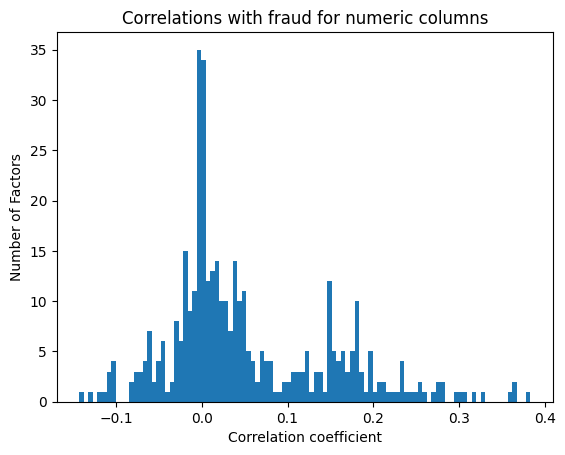

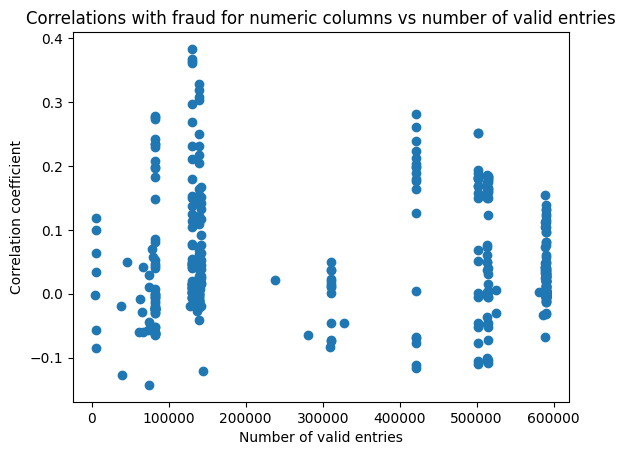

In [6]:
numeric_columns = int_columns + float_columns
correlations = dict()
all_fraud_nans = []
no_fraud_nans = []
const_values = []

for c in numeric_columns[2:]:
    erho = fraud_counts[c]/n_rows[c]
    evalue = sums[c]/n_rows[c]
    cross_term = covariance_sums[c]/n_rows[c]
    var_rho = erho*(1-erho)
    var_val = square_sums[c]/n_rows[c] - evalue**2
    if var_rho<0:
        print(erho, c, fraud_counts[c], n_rows[c])

    corr = (cross_term-erho*evalue)/np.sqrt(var_val*var_rho)
    if np.isnan(corr):
        if erho == 0:
            no_fraud_nans.append(c)
        elif erho == 1:
            all_fraud_nans.append(c)
        else:
            const_values.append(c)
    else:
        correlations[c] = [corr,n_rows[c]]
    

corrs = list(correlations.items())
corrs.sort(key = lambda x: -abs(x[1][0]))

plt.hist([c[1][0] for c in corrs], bins = 100)
plt.title('Correlations with fraud for numeric columns')
plt.xlabel('Correlation coefficient')
plt.ylabel('Number of Factors')
plt.show()

plt.scatter([c[1][1] for c in corrs], [c[1][0] for c in corrs])
plt.title('Correlations with fraud for numeric columns vs number of valid entries')
plt.ylabel('Correlation coefficient')
plt.xlabel('Number of valid entries')
plt.show()

In [7]:
df_merge[object_columns].head(15)

,ProductCD,card4,card6,P_emaildomain,R_emaildomain,M1,M2,M3,M4,M5,...,id_30,id_31,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,W,discover,credit,NaN,NaN,T,T,T,M2,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,W,mastercard,credit,gmail.com,NaN,NaN,NaN,NaN,M0,T,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,W,visa,debit,outlook.com,NaN,T,T,T,M0,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,W,mastercard,debit,yahoo.com,NaN,NaN,NaN,NaN,M0,T,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,H,mastercard,credit,gmail.com,NaN,NaN,NaN,NaN,NaN,NaN,...,Android 7.0,samsung browser 6.2,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
5,W,visa,debit,gmail.com,NaN,T,T,T,M1,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,W,visa,debit,yahoo.com,NaN,T,T,T,M0,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,W,visa,debit,mail.com,NaN,NaN,NaN,NaN,M0,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,H,visa,debit,anonymous.com,NaN,NaN,NaN,NaN,NaN,NaN,...,iOS 11.1.2,mobile safari 11.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
9,W,mastercard,debit,yahoo.com,NaN,T,T,T,M0,T,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
import copy
counters = {c:dict() for c in object_columns}

for chunk in pd.read_csv('../raw_data/train_merge.csv', chunksize = 10000):

    n_rows_total += chunk.shape[0]
    for c in object_columns:
        counter_update = counters[c]
        vals = chunk[['isFraud',c]].dropna().groupby(c).agg(count = (c, 'count'),total_sum = ('isFraud','sum')).reset_index().to_numpy()
        m = vals.shape[0]
        for i in range(m):
            name = vals[i,0]
            total = vals[i,1:]
            if name in counter_update:
                counter_update[name] += total
            else:
                counter_update[name] = copy.copy(total)
        counters[c] = counter_update


        
        


In [ ]:
for c,di in counters.items():
    if sum([val[0] for val in di.values()])>=n_rows_total/10:
        names = list()
        x_vals = list()
        y_vals = list()
        for name, counts in di.items():
            x_vals.append(counts[0])
            y_vals.append(counts[1])
            names.append(name)

        new_df = pd.DataFrame(
            {'Type':names, 
             'Counts': x_vals,
             'Total_Fraud':y_vals}
        )
        fig = px.scatter(new_df, x = 'Counts', y = 'Total_Fraud', hover_data = ['Type'])
        fig.show()
        